In [1]:
import torch
import torch.nn as nn
import torchvision

In [2]:
import torch
import torch.nn as nn
import torchvision
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision import transforms as T
from PIL import Image
import os
import matplotlib.pyplot as plt


class DataSetLoader_test(Dataset):
    def __init__(self, root_dir, transform=None, num_classes=101, return_pil=False):
        self.root_dir = root_dir
        self.transform = transform
        self.num_classes = num_classes
        # 如果 return_pil 为 True，则 __getitem__ 返回 PIL 图像而不是张量
        self.return_pil = return_pil

        # 收集所有 (img_path, label_idx)
        self.samples = []
        self.class_names = sorted(
            [
                d
                for d in os.listdir(root_dir)
                if os.path.isdir(os.path.join(root_dir, d))
            ]
        )[: self.num_classes]
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.class_names)}

        for cls_name in self.class_names:
            cls_dir = os.path.join(root_dir, cls_name)
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                    img_path = os.path.join(cls_dir, fname)
                    label = self.class_to_idx[cls_name]
                    self.samples.append((img_path, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")

        if self.return_pil:
            return image, label

        if self.transform is not None:
            image = self.transform(image)

        return image, label

In [3]:
import random


class DataSetLoader_train(Dataset):
    def __init__(
        self,
        root_dir,
        transform=None,
        num_classes=101,
        split_ratio=0.8,
        return_pil=False,
        dataclass="train",
    ):
        self.root_dir = root_dir
        self.transform = transform
        self.num_classes = num_classes
        self.split_ratio = split_ratio
        self.return_pil = return_pil
        self.dataclass = dataclass
        self.trainSamples = []
        self.validSamples = []
        self.class_names = sorted(
            [
                d
                for d in os.listdir(root_dir)
                if os.path.isdir(os.path.join(root_dir, d))
            ]
        )[: self.num_classes]
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.class_names)}
        self.train_count = {cls_name: 0 for cls_name in self.class_names}
        self.valid_count = {cls_name: 0 for cls_name in self.class_names}

        for cls_name in self.class_names:
            cls_dir = os.path.join(root_dir, cls_name)
            cls_samples = []
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                    img_path = os.path.join(cls_dir, fname)
                    label = self.class_to_idx[cls_name]
                    cls_samples.append((img_path, label))
            random.shuffle(cls_samples)
            split_idx = int(len(cls_samples) * self.split_ratio)
            train_split = cls_samples[:split_idx]
            valid_split = cls_samples[split_idx:]
            self.trainSamples.extend(train_split)  # 前80% 训练样本
            self.validSamples.extend(valid_split)  # 后20% 验证样本
            self.train_count[cls_name] += len(train_split)
            self.valid_count[cls_name] += len(valid_split)

    def __len__(self):
        if self.dataclass == "train":
            return len(self.trainSamples)
        else:
            return len(self.validSamples)

    def __getitem__(self, idx):
        if self.dataclass == "train":
            img_path, label = self.trainSamples[idx]
        else:
            img_path, label = self.validSamples[idx]
        image = Image.open(img_path).convert("RGB")

        if self.return_pil:
            return image, label

        if self.transform is not None:
            image = self.transform(image)
        else:
            transform = T.Compose(
                [
                    T.Resize((128, 128)),
                    T.ToTensor(),
                    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                ]
            )
            image = transform(image)

        return image, label

In [4]:
def remove_auxiliary_branches(model):
    m = model.module if isinstance(model, nn.DataParallel) else model
    if hasattr(m, 'aux1'):
        m.aux1 = None
    if hasattr(m, 'aux2'):
        m.aux2 = None
    return model

In [5]:
from tqdm import tqdm

def test_val(model, val_loader, criterion, device):
    model = remove_auxiliary_branches(model)
    model.eval()
    correct = 0
    total = 0
    total_loss = 0.0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="验证中"):
            images, labels = images.to(device), labels.to(device)
            if images.dim() == 5:
                bsz, ncrops, c, h, w = images.size()
                outputs = model(images.view(-1, c, h, w))
                if hasattr(outputs, 'logits'):
                    outputs = outputs.logits
                elif isinstance(outputs, tuple):
                    outputs = outputs[0]
                outputs = outputs.view(bsz, ncrops, -1).mean(dim=1)
            else:
                outputs = model(images)
                if hasattr(outputs, 'logits'):
                    outputs = outputs.logits
                elif isinstance(outputs, tuple):
                    outputs = outputs[0]
            loss = criterion(outputs, labels)
            total_loss += loss.item() * labels.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / max(total, 1)
    accuracy = correct / max(total, 1)
    return accuracy

def train(
    model,
    epoch,
    train_loader,
    optimizer,
    criterion,
    device,
    scheduler=None,
    val_loader=None,
):
    train_acc = []
    val_acc = []
    loss_history = []

    for ep in range(epoch):
        model.train()
        total_loss = 0.0
        correct = 0
        total = 0

        for images, labels in tqdm(train_loader, desc=f"训练中 [{ep+1}/{epoch}]"):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            # 支持 GoogLeNet 侧分支损失
            if isinstance(model, torch.nn.DataParallel):
                model_module = model.module
            else:
                model_module = model

            outputs = model(images)
            if (
                hasattr(model_module, "aux1") and hasattr(model_module, "aux2")
                and model_module.aux1 is not None and model_module.aux2 is not None
                and isinstance(outputs, tuple) and len(outputs) == 3
            ):
                main_output, aux1_output, aux2_output = outputs
                loss_main = criterion(main_output, labels)
                loss_aux1 = criterion(aux1_output, labels)
                loss_aux2 = criterion(aux2_output, labels)
                batch_loss = loss_main + 0.3 * (loss_aux1 + loss_aux2)
                outputs_for_acc = main_output
            else:
                # 兼容其他模型
                if hasattr(outputs, 'logits'):
                    outputs_for_acc = outputs.logits # type: ignore
                elif isinstance(outputs, tuple):
                    outputs_for_acc = outputs[0]
                else:
                    outputs_for_acc = outputs
                batch_loss = criterion(outputs_for_acc, labels)

            batch_loss.backward()
            optimizer.step()

            total_loss += batch_loss.item() * labels.size(0)
            _, predicted = outputs_for_acc.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

        avg_loss = total_loss / max(total, 1)
        accuracy = correct / max(total, 1)
        train_acc.append(accuracy)
        loss_history.append(avg_loss)

        val_acc_ = None
        if val_loader is not None:
            val_acc_ = test_val(model, val_loader, criterion, device)
            val_acc.append(val_acc_)

        if scheduler is not None:
            if val_acc_ is None:
                scheduler.step()
            else:
                scheduler.step(val_acc_)

        if val_acc_ is None:
            print(
                f"Epoch [{ep+1}/{epoch}] 平均损失: {avg_loss:.4f} 训练准确率: {accuracy:.4f}"
            )
        else:
            print(
                f"Epoch [{ep+1}/{epoch}] 平均损失: {avg_loss:.4f} 训练准确率: {accuracy:.4f} 验证准确率: {val_acc_:.4f}"
            )

    return train_acc, loss_history, val_acc


In [6]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

def _pick_cjk_font():
    candidates = [
        "Noto Sans CJK SC",
        "Noto Sans CJK",
        "SimHei",
        "Microsoft YaHei",
        "WenQuanYi Zen Hei",
        "Arial Unicode MS",
    ]
    available = {f.name for f in fm.fontManager.ttflist}
    for name in candidates:
        if name in available:
            return name
    return None

def _set_plot_font():
    font_name = _pick_cjk_font()
    if font_name:
        plt.rcParams["font.sans-serif"] = [font_name]
        plt.rcParams["axes.unicode_minus"] = False
        return True
    return False

def plot_metrics(train_acc, val_acc, loss):
    has_cjk_font = _set_plot_font()
    epochs = list(range(1, len(train_acc) + 1))

    plt.figure(figsize=(12, 5))

    ax1 = plt.subplot(1, 2, 1)
    ax1.plot(epochs, train_acc, label='training accuracy')
    if val_acc:
        ax1.plot(epochs, val_acc, label='validation accuracy')
    ax1.set_title('Training and Validation Accuracy' if has_cjk_font else 'Train/Val Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy' if has_cjk_font else 'Accuracy')
    ax1.legend()

    best_train_idx = max(range(len(train_acc)), key=lambda i: train_acc[i])
    ax1.scatter(epochs[best_train_idx], train_acc[best_train_idx], color='C0')
    ax1.annotate(
        f"train={train_acc[best_train_idx]:.3f}",
        (epochs[best_train_idx], train_acc[best_train_idx]),
        textcoords="offset points",
        xytext=(6, 6),
    )
    if val_acc:
        best_val_idx = max(range(len(val_acc)), key=lambda i: val_acc[i])
        ax1.scatter(epochs[best_val_idx], val_acc[best_val_idx], color='C1')
        ax1.annotate(
            f"val={val_acc[best_val_idx]:.3f}",
            (epochs[best_val_idx], val_acc[best_val_idx]),
            textcoords="offset points",
            xytext=(6, 6),
        )

    ax2 = plt.subplot(1, 2, 2)
    ax2.plot(epochs, loss, label='training loss')
    ax2.set_title('Training Loss' if has_cjk_font else 'Train Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss' if has_cjk_font else 'Loss')
    ax2.legend()

    best_loss_idx = min(range(len(loss)), key=lambda i: loss[i])
    ax2.scatter(epochs[best_loss_idx], loss[best_loss_idx], color='C0')
    ax2.annotate(
        f"min={loss[best_loss_idx]:.3f}",
        (epochs[best_loss_idx], loss[best_loss_idx]),
        textcoords="offset points",
        xytext=(6, 6),
    )

    plt.tight_layout()
    plt.show()


In [7]:
import os
from datetime import datetime

# 保存/加载检查点的实用函数（在新的 notebook cell 中执行）
def save_checkpoint(path, model, optimizer, scheduler=None, epoch=None, best_acc=None):
  os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
  # 如果使用了 DataParallel，保存 module 的 state_dict
  state_dict = model.module.state_dict() if hasattr(model, "module") else model.state_dict()
  checkpoint = {
    "epoch": epoch,
    "model_state_dict": state_dict,
    "optimizer_state_dict": optimizer.state_dict() if optimizer is not None else None,
    "scheduler_state_dict": scheduler.state_dict() if scheduler is not None else None,
    "best_acc": best_acc,
    "saved_at": datetime.utcnow().isoformat(),
  }
  torch.save(checkpoint, path)
  print(f"Saved checkpoint to {path}")

In [8]:
import random
from torchvision.transforms.v2 import ScaleJitter

train_dir = "/data/data_taohy/awesomeCopression/food101_images/train"
test_dir = "/data/data_taohy/awesomeCopression/food101_images/validation"


device = torch.device("cuda") if torch.cuda.is_available() else "cpu"

In [9]:
model = torchvision.models.googlenet(pretrained=False)
state_dict = torch.load('/data/data_taohy/modelReShow/GoogleNet/googlenet-1378be20.pth', map_location='cpu')
model.load_state_dict(state_dict)

in_features = model.fc.in_features  # GoogLeNet的全连接层
model.fc = torch.nn.Linear(in_features, 101)  # 替换为你自己的类别数

# 正则化：主分类器GAP前Dropout=0.4，辅助分类器Dropout=0.7
if hasattr(model, 'dropout'):
    model.dropout.p = 0.4
if hasattr(model, 'aux1') and model.aux1 is not None and hasattr(model.aux1, 'dropout'):
    model.aux1.dropout.p = 0.7 # type: ignore
if hasattr(model, 'aux2') and model.aux2 is not None and hasattr(model.aux2, 'dropout'):
    model.aux2.dropout.p = 0.7 # type: ignore

if torch.cuda.device_count() > 1:
    print("使用多卡训练, GPU 数量:", torch.cuda.device_count())
    model = nn.DataParallel(model)
model = model.to(device)

/data/xyjiang/anaconda3/envs/thy_env1/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/data/xyjiang/anaconda3/envs/thy_env1/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/data/xyjiang/anaconda3/envs/thy_env1/lib/python3.11/site-packages/torchvision/models/googlenet.py:47: FutureWarning: The default weight initialization of GoogleNet will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


使用多卡训练, GPU 数量: 4


In [10]:
transform_train = T.Compose([
    T.RandomResizedCrop(128, scale=(0.08, 1.0), ratio=(3/4, 4/3)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

transform_val = T.Compose([
    T.Resize(150),
    T.CenterCrop(128),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = DataSetLoader_train(
    root_dir=train_dir,
    num_classes=101,
    transform=transform_train,
    split_ratio=0.8,
    return_pil=False,
    dataclass="train",
)
val_dataset = DataSetLoader_train(
    root_dir=train_dir,
    num_classes=101,
    transform=transform_val,
    split_ratio=0.8,
    return_pil=False,
    dataclass="valid",
)


train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=8)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=8)

# 优化器：SGD+momentum
optimizer = torch.optim.SGD(
    model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4
)

# 学习率阶梯式衰减，每8个epoch乘以0.96（降低4%）
scheduler_base = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=8,  # 每8个epoch调整一次
    gamma=0.96   # 乘以0.96（降低4%）
)

criterion = nn.CrossEntropyLoss()


验证中: 100%|██████████| 237/237 [00:33<00:00,  7.04it/s]
/data/xyjiang/anaconda3/envs/thy_env1/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch [1/30] 平均损失: 5.9438 训练准确率: 0.2399 验证准确率: 0.4381


验证中: 100%|██████████| 237/237 [00:34<00:00,  6.91it/s]


Epoch [2/30] 平均损失: 2.7013 训练准确率: 0.3491 验证准确率: 0.5043


验证中: 100%|██████████| 237/237 [00:34<00:00,  6.90it/s]


...

Epoch [28/30] 平均损失: 2.0206 训练准确率: 0.5019 验证准确率: 0.6628


验证中: 100%|██████████| 237/237 [00:34<00:00,  6.90it/s]


Epoch [29/30] 平均损失: 2.0171 训练准确率: 0.5029 验证准确率: 0.6713


验证中: 100%|██████████| 237/237 [00:33<00:00,  7.05it/s]


Epoch [30/30] 平均损失: 2.0060 训练准确率: 0.5029 验证准确率: 0.6456


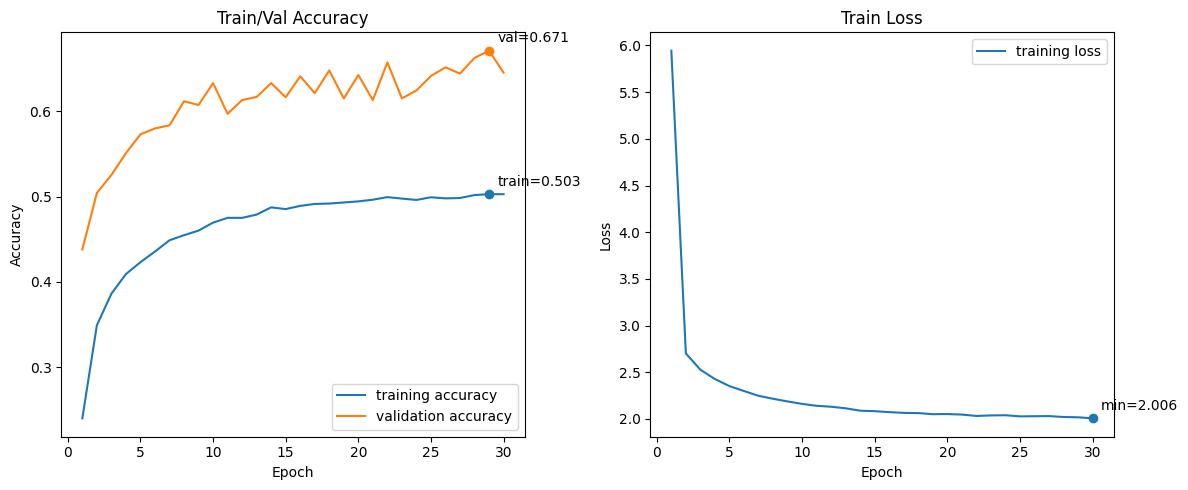

In [11]:
train_acc, loss, val_acc = train(
    model,
    epoch=30,
    train_loader=train_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    scheduler=scheduler_base,
    val_loader=val_loader,
 )

plot_metrics(train_acc, val_acc, loss)

In [12]:
def test(model, test_loader, device):
    model = remove_auxiliary_branches(model)
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="测试中"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = correct / total
    print(f"测试准确率: {accuracy:.4f}")

In [13]:
def practical_multi_scale_test(model, test_loader, device, scales=[150, 180], crop_size=128, do_flip=True):
    """
    多尺度+多裁剪+水平翻转测试时增强（TTA），适配常见推理增强方式。
    假设 test_loader 返回的 images 为 [batch, 3, H, W] tensor。
    """
    import numpy as np
    model = remove_auxiliary_branches(model)
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="多尺度TTA测试中"):
            images = images.to(device)
            labels = labels.to(device)
            batch_size, _, H, W = images.shape
            all_probs = []
            for scale in scales:
                # resize到不同尺度
                resized = torch.nn.functional.interpolate(images, size=(scale, scale), mode='bilinear', align_corners=False)
                # 多裁剪（四角+中心）
                crop_coords = [
                    (0, 0),
                    (scale - crop_size, 0),
                    (0, scale - crop_size),
                    (scale - crop_size, scale - crop_size),
                    ((scale - crop_size) // 2, (scale - crop_size) // 2),
                ]
                crops = []
                for (x, y) in crop_coords:
                    crop = resized[:, :, y:y+crop_size, x:x+crop_size]
                    crops.append(crop)
                # 水平翻转
                if do_flip:
                    crops += [torch.flip(c, dims=[3]) for c in crops]
                # [视图数, batch, 3, crop_size, crop_size] -> [视图数*batch, 3, crop_size, crop_size]
                all_views = torch.cat(crops, dim=0)
                outputs = model(all_views)
                if hasattr(outputs, 'logits'):
                    outputs = outputs.logits
                elif isinstance(outputs, tuple):
                    outputs = outputs[0]
                probs = torch.softmax(outputs, dim=1)
                # [视图数*batch, num_classes] -> [视图数, batch, num_classes]
                num_views = len(crops)
                probs = probs.view(num_views, batch_size, -1)
                probs = probs.mean(dim=0)  # batch, num_classes
                all_probs.append(probs.cpu().numpy())
            # 多尺度平均
            final_prob = np.mean(all_probs, axis=0)
            preds = np.argmax(final_prob, axis=1)
            correct += (preds == labels.cpu().numpy()).sum()
            total += batch_size
    acc = correct / total
    print(f"多尺度TTA测试准确率: {acc:.4f}")
    return acc


In [14]:
transform_test = T.Compose(
    [
        T.Resize(150), 
        T.CenterCrop(128), 
        T.ToTensor(),  
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)
test_dataset = DataSetLoader_test(
    root_dir=test_dir, num_classes=101, transform=transform_test
)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=8)
test(model, test_loader, device)

测试中: 100%|██████████| 395/395 [00:55<00:00,  7.15it/s]

测试准确率: 0.6418


In [15]:
practical_multi_scale_test(model, test_loader, device)

多尺度TTA测试中: 100%|██████████| 395/395 [01:38<00:00,  4.02it/s]

多尺度TTA测试准确率: 0.6319


np.float64(0.6319207920792079)

In [16]:
save_checkpoint(
    path="googlenet_food101_cheat_30.pth",
    model=model,
    optimizer=optimizer,
    scheduler=scheduler_base,
    epoch=80,
    best_acc=max(val_acc),
)

Saved checkpoint to googlenet_food101_cheat_30.pth


In [17]:
train_acc1, loss1, val_acc1 = train(
    model,
    epoch=50,
    train_loader=train_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    scheduler=scheduler_base,
    val_loader=val_loader,
 )



验证中: 100%|██████████| 237/237 [00:32<00:00,  7.20it/s]


Epoch [1/50] 平均损失: 2.0045 训练准确率: 0.5050 验证准确率: 0.6455


验证中: 100%|██████████| 237/237 [00:34<00:00,  6.91it/s]


Epoch [2/50] 平均损失: 2.0019 训练准确率: 0.5050 验证准确率: 0.6421


验证中: 100%|██████████| 237/237 [00:31<00:00,  7.45it/s]


...

Epoch [48/50] 平均损失: 1.9024 训练准确率: 0.5269 验证准确率: 0.6395


验证中: 100%|██████████| 237/237 [00:33<00:00,  7.01it/s]


Epoch [49/50] 平均损失: 1.9165 训练准确率: 0.5250 验证准确率: 0.6587


验证中: 100%|██████████| 237/237 [00:34<00:00,  6.97it/s]

Epoch [50/50] 平均损失: 1.8943 训练准确率: 0.5291 验证准确率: 0.6546


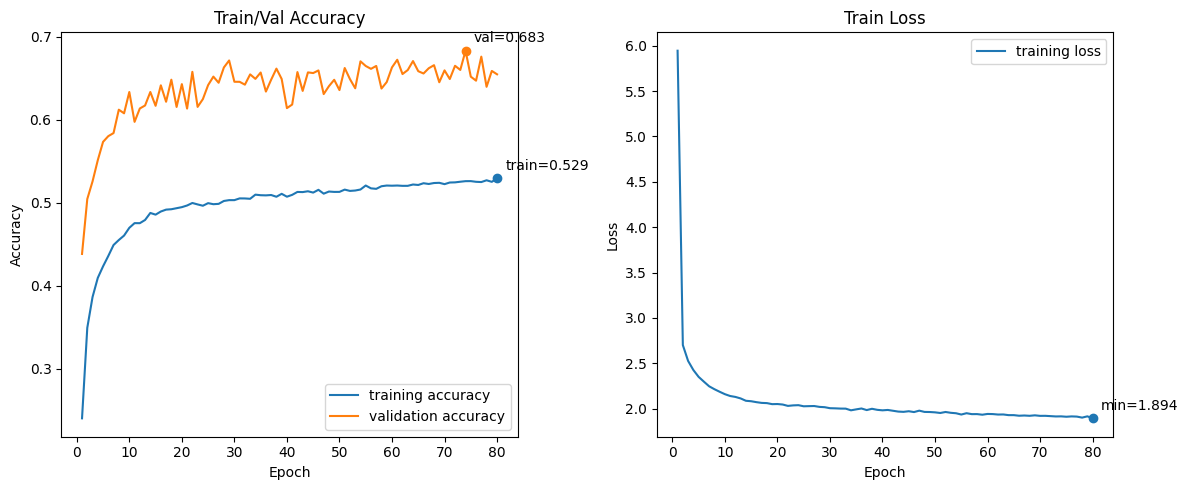

In [18]:
plot_metrics(train_acc+train_acc1, val_acc+val_acc1, loss+loss1)

In [19]:
save_checkpoint(
    path="googlenet_food101_cheat_80.pth",
    model=model,
    optimizer=optimizer,
    scheduler=scheduler_base,
    epoch=80,
    best_acc=max(val_acc1 + val_acc) if val_acc1 else max(val_acc),
)

Saved checkpoint to googlenet_food101_cheat_80.pth


In [20]:
test(model, test_loader, device)

测试中: 100%|██████████| 395/395 [00:50<00:00,  7.88it/s]

测试准确率: 0.6415


In [21]:
practical_multi_scale_test(model, test_loader, device)

多尺度TTA测试中: 100%|██████████| 395/395 [01:30<00:00,  4.37it/s]

多尺度TTA测试准确率: 0.6307


np.float64(0.6306534653465347)